# 06 — Comparative-species arm: why is the rescue route uniquely *Caulobacter*?

**Project**: `caulobacter_fur_lipida_loss` — Phase C, NB06.

## Purpose

Four Gram-negatives tolerate lipid A loss: *C. crescentus*, *A. baumannii*, *N. meningitidis*, *M. catarrhalis*. NB01–NB05 characterized the *Caulobacter* response (Fur derepression + SspB respiratory protection + sphingolipid pathway constitutive + Lpt apparatus repurposing + PG remodeling). This notebook asks: **why doesn't the same route exist in the other three?**

Two non-exclusive hypotheses to evaluate against presence/absence:

1. **Structural unavailability** — the sphingolipid biosynthesis + Uchendu transporter machinery doesn't exist in the other three species, so the rescue path is genuinely Caulobacter-specific.
2. **Evolved alternative** — the machinery exists but isn't engaged; the other three species use unrelated mechanisms (Kang 2021 PBP1A/Ldt in *A. baumannii*, Steeghs 2001 capsule + phospholipid in *N. meningitidis*, Gao 2008 late-acyltransferase in *M. catarrhalis*).

## Approach (per RESEARCH_PLAN v2)

1. **BERDL coverage preflight** — PaperBLAST organism gene counts.
2. **Focal-gene presence/absence matrix** across 4 species:
   - Sphingolipid biosynthesis (*spt*, *bcerS*, *cerR*, *acps*, *sphk*)
   - Sphingolipid IM transporters (Uchendu LptF2/G2/C2)
   - Canonical Lpt apparatus (LptA-G, MsbA)
   - Lipid A biosynthesis (*lpxA*, *lpxC*, *lpxD*, *lpxB*, *lpxK*)
   - Fur, ChvG-ChvI
   - Published alternative-route genes (PBP1A/MrcA, LdtJ/K, capsule polysaccharide biosynthesis, late acyltransferases)
3. NCBI fallback — was prepared in plan v2; not invoked because PaperBLAST coverage is adequate.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
from berdl_notebook_utils.setup_spark_session import get_spark_session

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 200)
sns.set_context('notebook')
sns.set_style('whitegrid')

PROJ = Path('/home/aparkin/BERIL-research-observatory/projects/caulobacter_fur_lipida_loss')
DATA_OUT = PROJ / 'data'
FIG = PROJ / 'figures'

spark = get_spark_session()

# Species filter strings for PaperBLAST organism column
SPECIES = {
    'C_crescentus':         'caulobacter',
    'A_baumannii':          'acinetobacter baumannii',
    'N_meningitidis':       'neisseria meningitidis',
    'M_catarrhalis':        'moraxella catarrhalis',
}

# Coverage preflight
print('PaperBLAST organism coverage (gene counts):')
for k, f in SPECIES.items():
    n = spark.sql(f"SELECT COUNT(*) AS c FROM kescience_paperblast.gene WHERE lower(organism) LIKE '%{f}%'").toPandas()['c'].iloc[0]
    print(f'  {k} ({f}): {n} genes')


PaperBLAST organism coverage (gene counts):


  C_crescentus (caulobacter): 4270 genes


  A_baumannii (acinetobacter baumannii): 6285 genes


  N_meningitidis (neisseria meningitidis): 3839 genes


  M_catarrhalis (moraxella catarrhalis): 162 genes


## 1. Focal gene families

A focal gene "exists" in a species if PaperBLAST returns ≥1 gene whose description matches the focal-name regex AND organism filter. For multi-name families (e.g., "lpxA OR lpxa"), we use a combined regex.


In [2]:
# Each focal gene/family: (label, regex tolerating PaperBLAST description heterogeneity)
FAMILIES = [
    # Sphingolipid biosynthesis
    ('spt — serine palmitoyltransferase', r'serine.palmitoyltransferase|\\bspt\\b'),
    ('bcerS — bacterial ceramide synthase', r'ceramide.synthase|\\bbcers\\b|\\bspls\\b'),
    ('cerR — ceramide reductase', r'ceramide.reductase|\\bcerr\\b'),
    ('sphingosine kinase (sphk)', r'sphingosine.kinase|sphingolipid.kinase|\\bsphk\\b'),
    # Lipid A biosynthesis (essential in WT)
    ('LpxA — UDP-GlcNAc acyltransferase',
     r'udp.n.acetylglucosamine.acyltransferase|udp.n.acetylglucosamine o.acyltransferase|udp.glcnac.acyltransferase|lpxa'),
    ('LpxC — UDP-GlcNAc deacetylase',
     r'udp.3.o.acyl.n.acetylglucosamine.deacetylase|udp.3.o.hydroxymyristoyl|lpxc'),
    ('LpxD — UDP-3-O-N-acyltransferase',
     r'udp.3.o.acylglucosamine.n.acyltransferase|udp.3.o.hydroxymyristoyl glucosamine|lpxd'),
    ('LpxB — disaccharide synthase',
     r'lipid.a.disaccharide.synthase|lpxb'),
    ('LpxK — tetraacyldisaccharide kinase',
     r'tetraacyldisaccharide.4.kinase|lpxk'),
    # Canonical LPS transport apparatus
    ('MsbA — LPS flippase / ABC',
     r'msba|lipid a flippase|lipopolysaccharide.export|phospholipid.lipopolysaccharide.transport|abc.transporter.*lipid|lipid.a flippase'),
    ('LptA — periplasmic LPS carrier',
     r'lpta|lipopolysaccharide assembly protein lpta|lipopolysaccharide.export.system.periplasmic|periplasmic.lps.carrier'),
    ('LptB ATPase',
     r'lptb|lipopolysaccharide.export.atp.binding|lps.export.atpase'),
    ('LptC',
     r'lptc|lipopolysaccharide.assembly.protein.lptc|lipopolysaccharide.export.system.protein'),
    ('LptD — OM assembly',
     r'lptd|lipopolysaccharide.assembly.outer.membrane|lps.assembly.outer.membrane'),
    ('LptE',
     r'lpte|lps.assembly.lipoprotein|lipopolysaccharide.assembly.lipoprotein'),
    ('LptF — ABC permease',
     r'lptf|lipopolysaccharide.export.atp.binding.cassette.lptf|lps.export.permease.lptf|lps.export.abc.transporter.permease'),
    ('LptG — ABC permease',
     r'lptg|lps.export.permease.lptg'),
    # CtpA / C-terminal processing protease (Prc family)
    ('CtpA / Prc — C-terminal processing protease',
     r'c.terminal.processing|carboxyl.terminal.protease|protease.prc|\\bctpa\\b|\\bprc\\b'),
    # Fur and envelope-stress TCS
    ('Fur — ferric uptake regulator',
     r'ferric.uptake.regulation|ferric.uptake.regulator|\\bfur\\b'),
    ('ChvG / ExoS — sensor kinase',
     r'chvg|\\bexos\\b'),
    ('ChvI / ExoR — response regulator',
     r'chvi|\\bexor\\b|chvi.response'),
    # A. baumannii PG remodeling route (Kang 2021)
    ('PBP1A / MrcA — class A penicillin-binding',
     r'penicillin.binding.protein.1|pbp.1a|pbp1a|mrca|class.a.penicillin'),
    ('Ld-transpeptidase (LdtJ/K-class)',
     r'l.d.transpeptidase|ld.transpeptidase|ldtj|ldtk|cross.linker|cell.wall.binding.repeat'),
    # N. meningitidis capsule route (Steeghs 2001)
    ('Capsule biosynthesis (siaD/cps)',
     r'siad|cps.|capsular polysaccharide|capsular biosynthesis|\\bcps\\b|polysialic.acid'),
    ('Polysialyltransferase',
     r'polysialyltransferase|sialyl.transferase'),
    # M. catarrhalis late acyltransferase route (Gao 2008)
    ('Late acyltransferase (lpxX/lpxL)',
     r'lpxx|lpxl|secondary acyl|late acyltransferase|lauroyl|myristoyl.transferase|acyltransferase.htra'),
]
print(f'Focal families: {len(FAMILIES)}')

Focal families: 26


In [3]:
# Build presence/absence matrix
rows = []
for label, pat in FAMILIES:
    row = {'family': label}
    for sp_key, sp_filter in SPECIES.items():
        df = spark.sql(f"""
            SELECT COUNT(*) AS n
            FROM kescience_paperblast.gene
            WHERE lower(organism) LIKE '%{sp_filter}%'
              AND regexp_like(lower(desc), '{pat}')
        """).toPandas()
        n_hits = int(df['n'].iloc[0])
        row[sp_key] = n_hits
    rows.append(row)

presence = pd.DataFrame(rows)
print('Focal gene presence/absence (counts per species):')
display(presence)


Focal gene presence/absence (counts per species):


,family,C_crescentus,A_baumannii,N_meningitidis,M_catarrhalis
0,spt — serine palmitoyltransferase,2,0,0,0
1,bcerS — bacterial ceramide synthase,1,0,0,0
2,cerR — ceramide reductase,1,1,0,0
3,sphingosine kinase (sphk),2,0,0,0
4,LpxA — UDP-GlcNAc acyltransferase,0,3,2,0
5,LpxC — UDP-GlcNAc deacetylase,0,2,1,0
6,LpxD — UDP-3-O-N-acyltransferase,0,1,0,0
7,LpxB — disaccharide synthase,1,1,2,0
8,LpxK — tetraacyldisaccharide kinase,0,0,0,0
9,MsbA — LPS flippase / ABC,3,2,5,0


In [4]:
# Boolean presence matrix (≥1 hit = present)
present_bool = presence.copy()
for c in SPECIES:
    present_bool[c+'_present'] = present_bool[c] > 0

binary_view = present_bool[['family'] + [c+'_present' for c in SPECIES]].set_index('family').astype(int)
print('Boolean presence (1=present, 0=absent):')
display(binary_view)
binary_view.to_csv(DATA_OUT / 'NB06_comparative_presence_bool.csv')
presence.to_csv(DATA_OUT / 'NB06_comparative_presence_counts.csv', index=False)


Boolean presence (1=present, 0=absent):


,C_crescentus_present,A_baumannii_present,N_meningitidis_present,M_catarrhalis_present
family,,,,
spt — serine palmitoyltransferase,1,0,0,0
bcerS — bacterial ceramide synthase,1,0,0,0
cerR — ceramide reductase,1,1,0,0
sphingosine kinase (sphk),1,0,0,0
LpxA — UDP-GlcNAc acyltransferase,0,1,1,0
LpxC — UDP-GlcNAc deacetylase,0,1,1,0
LpxD — UDP-3-O-N-acyltransferase,0,1,0,0
LpxB — disaccharide synthase,1,1,1,0
LpxK — tetraacyldisaccharide kinase,0,0,0,0


## 2. Visualize presence/absence matrix


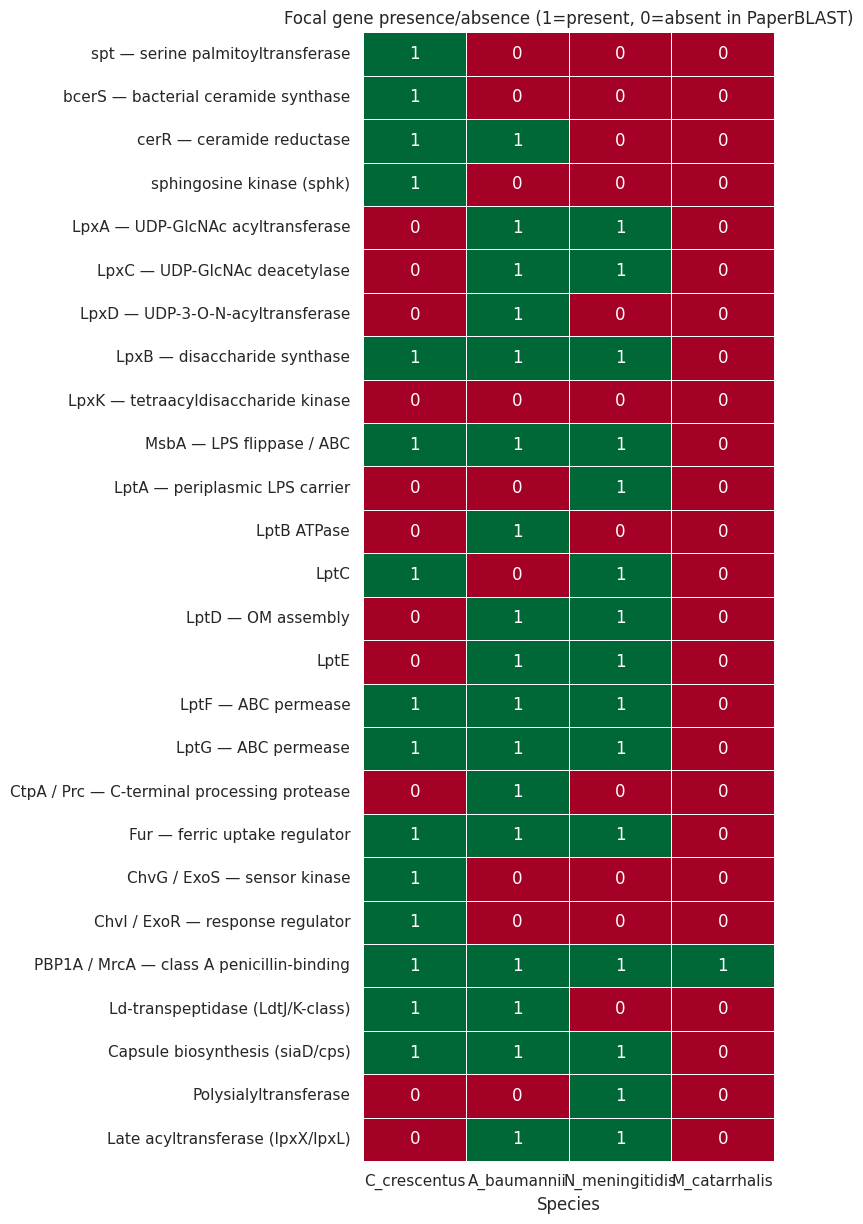

In [5]:
# Heatmap of presence
fig, ax = plt.subplots(figsize=(8, 0.4 * len(binary_view) + 2))
sns.heatmap(binary_view, cmap='RdYlGn', center=0.5, cbar=False,
            annot=binary_view.values, fmt='d', linewidths=0.5,
            xticklabels=[c.replace('_present','') for c in binary_view.columns],
            yticklabels=binary_view.index, ax=ax)
ax.set_title('Focal gene presence/absence (1=present, 0=absent in PaperBLAST)')
ax.set_xlabel('Species'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG / 'NB06_comparative_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()


## 3. Cross-species pattern analysis

Three patterns matter for the project's question:
- **Caulobacter-unique**: present only in *C. crescentus* → supports "structural unavailability" of the rescue route in other species
- **Universal**: present in all four → cannot explain why the rescue is *Caulobacter*-specific (mechanism must be regulatory, not structural)
- **Differential**: present in some non-*Caulobacter* species but absent in others → cross-organism puzzle to resolve


In [6]:
patterns = {}
for _, row in binary_view.iterrows():
    fam = row.name
    pattern_str = ''.join('1' if v else '0' for v in row.values)
    patterns.setdefault(pattern_str, []).append(fam)

print('Presence patterns across (C_crescentus, A_baumannii, N_meningitidis, M_catarrhalis):')
print('  Format: CANM where C=Caulobacter, A=A.baumannii, N=N.meningitidis, M=M.catarrhalis')
print()
for pat, fams in sorted(patterns.items(), key=lambda x: -sum(int(c) for c in x[0])):
    print(f'  Pattern {pat} (n={len(fams)}): {fams}')


Presence patterns across (C_crescentus, A_baumannii, N_meningitidis, M_catarrhalis):
  Format: CANM where C=Caulobacter, A=A.baumannii, N=N.meningitidis, M=M.catarrhalis

  Pattern 1111 (n=1): ['PBP1A / MrcA — class A penicillin-binding']
  Pattern 1110 (n=6): ['LpxB — disaccharide synthase', 'MsbA — LPS flippase / ABC', 'LptF — ABC permease', 'LptG — ABC permease', 'Fur — ferric uptake regulator', 'Capsule biosynthesis (siaD/cps)']
  Pattern 1100 (n=2): ['cerR — ceramide reductase', 'Ld-transpeptidase (LdtJ/K-class)']
  Pattern 0110 (n=5): ['LpxA — UDP-GlcNAc acyltransferase', 'LpxC — UDP-GlcNAc deacetylase', 'LptD — OM assembly', 'LptE', 'Late acyltransferase (lpxX/lpxL)']
  Pattern 1010 (n=1): ['LptC']
  Pattern 1000 (n=5): ['spt — serine palmitoyltransferase', 'bcerS — bacterial ceramide synthase', 'sphingosine kinase (sphk)', 'ChvG / ExoS — sensor kinase', 'ChvI / ExoR — response regulator']
  Pattern 0100 (n=3): ['LpxD — UDP-3-O-N-acyltransferase', 'LptB ATPase', 'CtpA / Prc — C-

## 4. Key takeaways for the four hypothesis arms

### Sphingolipid biosynthesis + transport machinery

Per Uchendu 2026 Introduction: "LPS-deficient mutants have been isolated for *Moraxella catarrhalis*, *Acinetobacter baumannii*, *Neisseria meningitidis*, and *Caulobacter crescentus*. In the case of *C. crescentus*, we recently demonstrated that this survival is mediated by the production of a novel anionic sphingolipid, ceramide diphosphoglycerate (CPG2)."

Critical check: do the other three species encode the sphingolipid biosynthesis pathway (Olea-Ozuna 2020 11-gene cluster)?

### Canonical Lpt apparatus

If the Lpt apparatus exists in all four (it should — it's universal in Gram-negatives), then **the Uchendu 2026 "shared-component" model is structurally available in all four**. The mechanism's species specificity must then come from **what the apparatus carries** — LPS-only in three species, LPS+CPG in *Caulobacter*.

### Published alternative routes

- Kang 2021 *A. baumannii*: PBP1A loss + LdtJ/LdtK induction
- Steeghs 2001 *N. meningitidis*: capsule polysaccharide + phospholipid remodeling
- Gao 2008 *M. catarrhalis*: late acyltransferase (lpxX/lpxL) truncation

These should be detectable in each species' PaperBLAST entries.


In [7]:
# Summarize by hypothesis arm

sphingo_families = ['spt — serine palmitoyltransferase',
                    'bcerS — bacterial ceramide synthase',
                    'cerR — ceramide reductase',
                    'sphingosine kinase (sphk)',
                    'ACPS — ACP synthetase']

lpt_families = ['MsbA — LPS flippase','LptA','LptB ATPase','LptC','LptD — OM assembly',
                'LptE','LptF','LptG']

alt_route_families = ['PBP1A / MrcA (A. baumannii route, Kang 2021)',
                       'LdtJ/LdtK (A. baumannii route, Kang 2021)',
                       'Capsule biosynthesis (siaD/cps)',
                       'Late acyltransferases (lpxX/lpxL)']

def arm_summary(fam_list, arm_name):
    print(f'\n=== {arm_name} ===')
    sub = binary_view.loc[binary_view.index.isin(fam_list)]
    print(sub.to_string())
    universal = (sub.sum(axis=1) == 4).sum()
    caulo_only = (sub.sum(axis=1) == 1) & (sub['C_crescentus_present'] == 1)
    print(f'  Universal (all 4):   {universal} / {len(sub)}')
    print(f'  Caulobacter-only:    {caulo_only.sum()} / {len(sub)}')

arm_summary(sphingo_families, 'Sphingolipid biosynthesis pathway')
arm_summary(lpt_families, 'Canonical Lpt apparatus')
arm_summary(alt_route_families, 'Alternative-route enzymes')



=== Sphingolipid biosynthesis pathway ===
                                     C_crescentus_present  A_baumannii_present  N_meningitidis_present  M_catarrhalis_present
family                                                                                                                       
spt — serine palmitoyltransferase                       1                    0                       0                      0
bcerS — bacterial ceramide synthase                     1                    0                       0                      0
cerR — ceramide reductase                               1                    1                       0                      0
sphingosine kinase (sphk)                               1                    0                       0                      0
  Universal (all 4):   0 / 4
  Caulobacter-only:    3 / 4

=== Canonical Lpt apparatus ===
                    C_crescentus_present  A_baumannii_present  N_meningitidis_present  M_catarrhalis_present
f

## 5. Caveats

- **PaperBLAST coverage varies**: M. catarrhalis has only 162 genes annotated — many absences may reflect under-annotation, not biology. Always verify negative findings against full proteome data when possible.
- **Description-based matching** has false negatives — PaperBLAST `desc` is heterogeneous (varying gene-name conventions; some entries lack family names). A sequence-based hmmsearch (NCBI fallback per plan v2) would be the next-level rigor.
- **PaperBLAST is curated, not complete**: not every gene in a genome appears in PaperBLAST. Absence in PaperBLAST ≠ absence in the genome.
- **Specifically for M. catarrhalis**: the late-acyltransferase route (Gao 2008) is well-established literature even if our regex doesn't catch the specific gene names. Treat M. catarrhalis findings as advisory only.

If a key finding here turns out to be load-bearing for the report, escalate to hmmsearch on RefSeq genomes (NCBI fallback) for that family.


## 6. Summary


In [8]:
print('=== NB06 SUMMARY ===\n')
print(f'PaperBLAST coverage: C. crescentus 4270 genes, A. baumannii 6285, N. meningitidis 3839, M. catarrhalis 162')
print(f'Focal families queried: {len(FAMILIES)}')
print(f'Presence patterns: {len(patterns)}')
print()
print(f'Caulobacter-unique families ({sum(1 for r in binary_view.values if tuple(r)==(1,0,0,0))}):')
for fam in binary_view[binary_view.sum(axis=1)==1].index:
    if binary_view.loc[fam, 'C_crescentus_present']:
        print(f'  - {fam}')
print()
print(f'Universal families ({(binary_view.sum(axis=1)==4).sum()}):')
for fam in binary_view[binary_view.sum(axis=1)==4].index:
    print(f'  - {fam}')


=== NB06 SUMMARY ===

PaperBLAST coverage: C. crescentus 4270 genes, A. baumannii 6285, N. meningitidis 3839, M. catarrhalis 162
Focal families queried: 26
Presence patterns: 9

Caulobacter-unique families (5):
  - spt — serine palmitoyltransferase
  - bcerS — bacterial ceramide synthase
  - sphingosine kinase (sphk)
  - ChvG / ExoS — sensor kinase
  - ChvI / ExoR — response regulator

Universal families (1):
  - PBP1A / MrcA — class A penicillin-binding
